In [1]:
from imolcryff.calculator import DihedralCalculator, load_g16scan
from imolcryff.io.rdkit import atoms2rdkit
from imolcryff.trainer.dmff_utils import  *
from imolcryff.trainer import mse_energy, DihedralTrainer
from ase.io import read
from ase.visualize import view
from jax import value_and_grad, jit, vmap

import matplotlib.pyplot as plt

/Users/srak/apl/iMolCRAFT/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:
pdbfile = "dmc.pdb"
atoms = read(pdbfile)
mol, mol2d, _ = atoms2rdkit(atoms)
calculator = DihedralCalculator(atoms, mol, "dmc" "temp_directory")
calculator.scan_list

[[1, 0, 2, 8], [1, 0, 3, 4], [0, 2, 8, 9], [0, 3, 4, 5]]

In [3]:
# # check dihedral atom index -> 1,0,2,8
# view(load_g16scan("dmc_dihed_0.log")[2])
# # check dihedral atom index -> 0,2,8,9
# view(load_g16scan("dmc_dihed_2.log")[2])

In [4]:
calculator.scan_list  = [calculator.scan_list[0] , calculator.scan_list[2]]
calculator.qm_calculators = [calculator.qm_calculators[0], calculator.qm_calculators[2]]
calculator.ff_calculators = [calculator.ff_calculators[0], calculator.ff_calculators[2]]
calculator.qm_scan = [calculator.qm_scan[0], calculator.qm_scan[2]]
calculator.ff_scan = [calculator.ff_scan[0], calculator.ff_scan[2]]

calculator.qm_scan[0]["angle_deg"], \
calculator.qm_scan[0]["energy_kjmol"], \
calculator.qm_scan[0]["atoms"], \
      = load_g16scan("dmc_dihed_0.log")

calculator.qm_scan[1]["angle_deg"], \
calculator.qm_scan[1]["energy_kjmol"], \
calculator.qm_scan[1]["atoms"], \
      = load_g16scan("dmc_dihed_2.log")

In [5]:
calculator.do_ffscan("dmc.xml", angles="QM", ini_geom="FF")
# calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

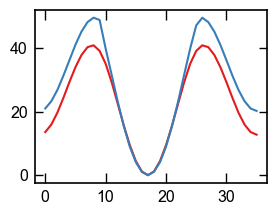

In [6]:
plt.plot(calculator.qm_scan[0]["energy_kjmol"])
plt.plot(calculator.ff_scan[0]["energy_kjmol"])

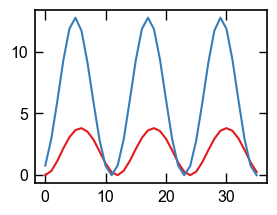

In [7]:
plt.plot(calculator.qm_scan[1]["energy_kjmol"])
plt.plot(calculator.ff_scan[1]["energy_kjmol"])

In [8]:
len(calculator.qm_scan)

2

In [9]:
def loss_energy(ffparams, ff, topology, positions, pairs, y_gt):
    ff_d = update_ffinfo_from_params(ff, ffparams)
    ffparams_wo_charge = {}
    for key in ffparams.keys():
        if key == "NonbondedForce":
            ffparams_wo_charge[key] = {}
            for key2 in ffparams[key].keys():
                if key2 != "charges":
                    ffparams_wo_charge[key][key2] = ffparams[key][key2]
        elif key == "VsiteForce":
            pass
        else:
            ffparams_wo_charge[key] = ffparams[key]

    pots = ff_d.createPotential(topology) # should be pdb topology wo vsites
    efunc = pots.getPotentialFunc()
    batched_efunc = vmap(lambda x: efunc(x, None, pairs[0], ffparams_wo_charge))
    e_ff = batched_efunc(positions)
    e_ff = e_ff 
    y_gt = y_gt 
    # print(f"e_ff: {e_ff}")
    # print(f"y_gt: {y_gt}")
    loss = mse_energy(e_ff, y_gt, weight_scheme="boltzmann", norm_var=True, zeropoint="qmmin")
    # print(f"loss: {loss}")
    return loss

In [10]:
tr = DihedralTrainer(
    ffxml="dmc.xml",
    pdbfile=pdbfile,
    calculator=calculator,
    opt_fftypes=["PeriodicTorsionForce/proper_k"],
    loss_fn=loss_energy,
    relax_steps=1,
    lr=0.1,
    clip=0.5
)

In [11]:
tr.setup()

In [12]:
tr.fit(steps=10)

Epoch 0 completed in 27.14 seconds.
Loss:  10.643234262804274
Best Loss:  10.643234262804274 at epoch  0
Epoch 1 completed in 20.32 seconds.
Loss:  8.322564787835521
Best Loss:  8.322564787835521 at epoch  1
Epoch 2 completed in 18.52 seconds.
Loss:  7.197568972186702
Best Loss:  7.197568972186702 at epoch  2
Epoch 3 completed in 18.14 seconds.
Loss:  6.162340701886792
Best Loss:  6.162340701886792 at epoch  3
Epoch 4 completed in 18.43 seconds.
Loss:  5.195256673546908
Best Loss:  5.195256673546908 at epoch  4
Epoch 5 completed in 19.03 seconds.
Loss:  4.353675895393435
Best Loss:  4.353675895393435 at epoch  5
Epoch 6 completed in 19.40 seconds.
Loss:  3.5879890135260926
Best Loss:  3.5879890135260926 at epoch  6
Epoch 7 completed in 18.94 seconds.
Loss:  2.9112161175737614
Best Loss:  2.9112161175737614 at epoch  7
Epoch 8 completed in 18.78 seconds.
Loss:  2.3200150780619055
Best Loss:  2.3200150780619055 at epoch  8
Epoch 9 completed in 18.73 seconds.
Loss:  1.8149297750243827
Bes

In [13]:
tr.relax_steps = 100
tr.fit(steps=300)

Epoch 11 completed in 0.12 seconds.
Loss:  1.0490257190643408
Best Loss:  1.0490257190643408 at epoch  11
Epoch 12 completed in 0.13 seconds.
Loss:  0.7779949405582336
Best Loss:  0.7779949405582336 at epoch  12
Epoch 13 completed in 0.12 seconds.
Loss:  0.57425894306631
Best Loss:  0.57425894306631 at epoch  13
Epoch 14 completed in 0.12 seconds.
Loss:  0.43082748996712467
Best Loss:  0.43082748996712467 at epoch  14
Epoch 15 completed in 0.12 seconds.
Loss:  0.3400204344250729
Best Loss:  0.3400204344250729 at epoch  15
Epoch 16 completed in 0.12 seconds.
Loss:  0.2936572613598456
Best Loss:  0.2936572613598456 at epoch  16
Epoch 17 completed in 0.12 seconds.
Loss:  0.28329266610445636
Best Loss:  0.28329266610445636 at epoch  17
Epoch 18 completed in 0.12 seconds.
Loss:  0.3004861626147997
Best Loss:  0.28329266610445636 at epoch  17
Epoch 19 completed in 0.12 seconds.
Loss:  0.3370873696159633
Best Loss:  0.28329266610445636 at epoch  17
Epoch 20 completed in 0.12 seconds.
Loss:  0

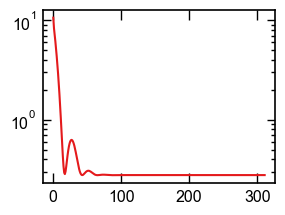

In [14]:
# plt.xscale("log")
plt.yscale("log")
plt.plot(tr.epochs, tr.losses)

In [15]:
# view(calculator.ff_scan[0]["atoms"])

In [16]:
calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

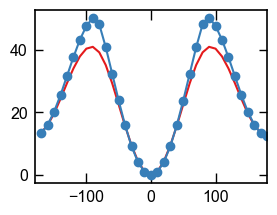

In [17]:
plt.xlim(-180,180)
plt.plot(calculator.qm_scan[0]["angle_deg"], calculator.qm_scan[0]["energy_kjmol"])
plt.plot(np.array(calculator.ff_scan[0]["angle_deg"]), calculator.ff_scan[0]["energy_kjmol"], marker="o")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])-180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])+180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")

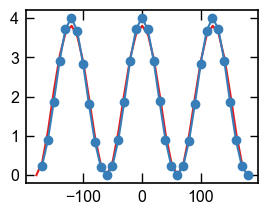

In [19]:
plt.plot(calculator.qm_scan[1]["angle_deg"], calculator.qm_scan[1]["energy_kjmol"])
plt.plot(calculator.ff_scan[1]["angle_deg"], calculator.ff_scan[1]["energy_kjmol"], marker="o")